<a href="https://colab.research.google.com/github/Julian6262/the_founder/blob/main/%D0%94%D0%97-16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Используя знания из практической части урока и функцию `blur_face` (размытие), проведите следующий эксперимент:
1. Найдите фото любого известного актера или актрисы.
2. Распознайте лицо на фотографии. Выделите лицо овалом. Какой метод для рисования овала использовать, вы должны найти самостоятельно.
3. Выделите на изображении глаза. Выделите их кружком. Если вы чувствуете в себе суперсилу и дополнительный бекграунд знаний, и хотите получить больше баллов за задание, то нарисуйте вместо кружков солнцезащитные очки (картинку очков можно найти в интернете, задача их правильно масштабировать и разместить).
4. Все лицо кроме глаз необходимо "заблюрить" (размыть) с помощью функции `blur_face` (функция объявлена ниже).




Оценка за задание:
* 1 балл - задача решена с помощью куратора, лицо распознано прямоугольником, глаза кругом.
* 2 балла - задача решена с незначительными подсказками куратора, лицо распознано прямоугольником или кругом, глаза кругом, лицо размыто.
* 3 балла - задача решена самостоятельно, лицо распознано овалом, глаза кругом, удалось заблюрить лицо, не затронув глаза.
* 4 балла - задача решена самостоятельно на 3 балла, удалось нарисовать очки с подсказкой куратора, недостаточна соблюдена симметрия расположения очков или недостаточно учтены их размеры.
* 5 баллов - задача полностью решена самостоятельно, все пункты выполнены.

In [ ]:
import cv2
import gdown
from matplotlib import pyplot

In [ ]:
gdown.download('https://storage.yandexcloud.net/dba-storage/OpenCV/1.jpg', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/dba-storage/OpenCV/2.jpg', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/dba-storage/OpenCV/3.jpg', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/dba-storage/OpenCV/4.jpg', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/dba-storage/OpenCV/5.jpg', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/dba-storage/OpenCV/6.jpg', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/dba-storage/OpenCV/7.jpg', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/dba-storage/OpenCV/8.jpg', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/dba-storage/OpenCV/glasses.png', None, quiet=True)

In [ ]:
def blur_face(img):
    (h, w) = img.shape[:2]
    dW = int(w / 3.0)
    dH = int(h / 3.0)
    if dW % 2 == 0:
        dW -= 1
    if dH % 2 == 0:
        dH -= 1
    return cv2.GaussianBlur(img, (dW, dH), 0)


def change_face(path, glass_width=0.2, blur=True):
    img = cv2.imread(path)
    img2 = img.copy()
    glass_img = cv2.imread('./glasses.png')

    classifier_face = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")
    bboxes = classifier_face.detectMultiScale(img, scaleFactor=2, minNeighbors=1, minSize=(50, 50))

    for box in bboxes:
        x, y, width, height = box
        # найденная область с лицом
        face = img2[y:y + height, x:x + width]
        eyes = classifier_eye.detectMultiScale(face, minSize=(70, 70))

        if len(eyes) > 1:
            x_eye1, y_eye1, w_eye1, h_eye1 = eyes[0]
            x_eye2, y_eye2, w_eye2, h_eye2 = eyes[1]
            # вычисляем среднюю высоту и среднее значение "y" по двум глазам
            y_center = ((y_eye1 + h_eye1 / 2) + (y_eye2 + h_eye2 / 2)) / 2
            h_center = (h_eye1 / 2 + h_eye2 / 2) / 2
            if x_eye1 > x_eye2:
                x_eye1, x_eye2 = x_eye2, x_eye1

            # задаем границы двух глаз с возможностью расширения по ширине (glass_width)
            y1 = int(y_center - h_center)
            y2 = int(y_center + h_center)
            x1 = int(x_eye1 - (x_eye2 - x_eye1) * glass_width) if x_eye1 - (x_eye2 - x_eye1) * glass_width > 0 else 0
            x2 = int(x_eye2 + w_eye2 + (x_eye2 - x_eye1) * glass_width)

            eyes = face[y1:y2, x1:x2].copy()

            # заблюрить лицо
            if blur:
                img2[y:y + height, x:x + width] = blur_face(face)
            # Рисуем овал, обнаруженное лицо. Код именно здесь, чтоб овал не скрывался за блюром
            f_center = (int(x + 0.5 * width), int(y + 0.5 * height))
            axes_length = (width // 2, 2 * height // 3)
            angle, start_angle, end_angle = 0, 0, 360
            cv2.ellipse(img2, f_center, axes_length, angle, start_angle, end_angle, (0, 0, 255), 3)

            # Масштабируем очки до размера границ двух глаз
            w_eyes, h_eyes = eyes.shape[:2]
            glass_img_small = cv2.resize(glass_img, (h_eyes, w_eyes), interpolation=cv2.INTER_AREA)
            # Сделаем очки черно-белые и применим инвариантный бинарный порог
            gray_mask = cv2.cvtColor(glass_img_small, cv2.COLOR_BGR2GRAY)
            ret, mask = cv2.threshold(gray_mask, 50, 255, cv2.THRESH_BINARY_INV)
            # Чтобы инвертировать маску в OpenCV, мы используем функцию cv2.bitwise_not(),
            # которая выполняет побитовую операцию not над отдельными пикселями.
            mask_inv = cv2.bitwise_not(mask)
            # побитовое AND для двух изображений, результирующая - пиксели присутствующие на обоих изображениях
            masked_glass = cv2.bitwise_and(glass_img_small, glass_img_small, mask=mask)
            masked_face = cv2.bitwise_and(eyes, eyes, mask=mask_inv)
            # Объединяем глаза и очки
            face[y1:y2, x1:x2] = cv2.add(masked_glass, masked_face)

    fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(15, 8))
    ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax1.xaxis.set_ticks([])
    ax1.yaxis.set_ticks([])
    ax1.set_title('Исходное изображение')

    ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    ax2.xaxis.set_ticks([])
    ax2.yaxis.set_ticks([])
    ax2.set_title('Распознанные лица и глаза')
    pyplot.show()

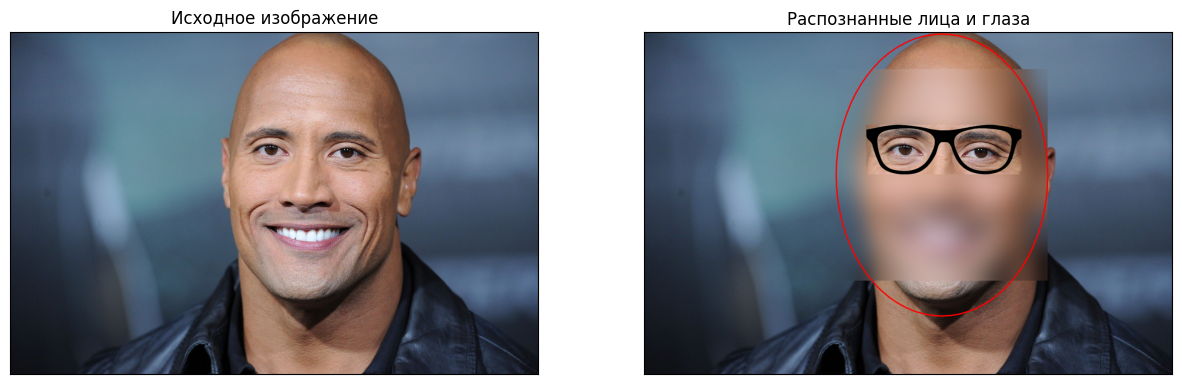

In [ ]:
change_face('./1.jpg')

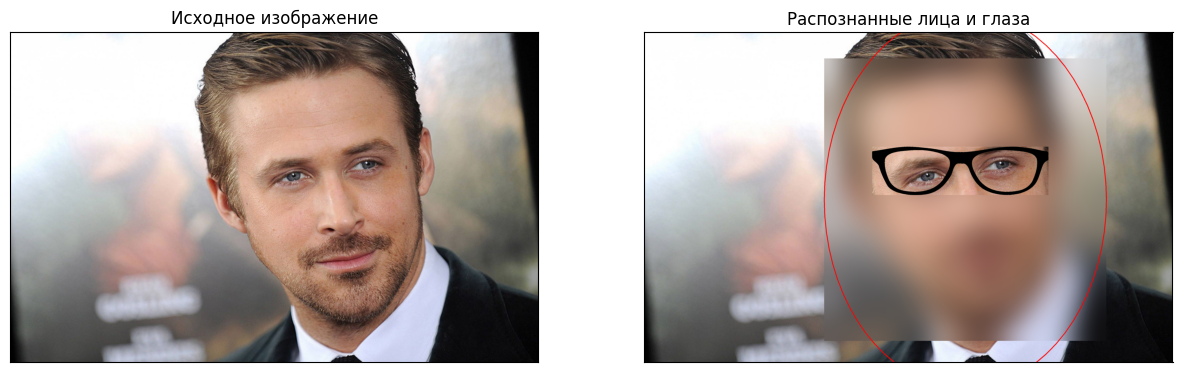

In [ ]:
change_face('./2.jpg', glass_width=0.4)  # glass_width - ширина очков на лице

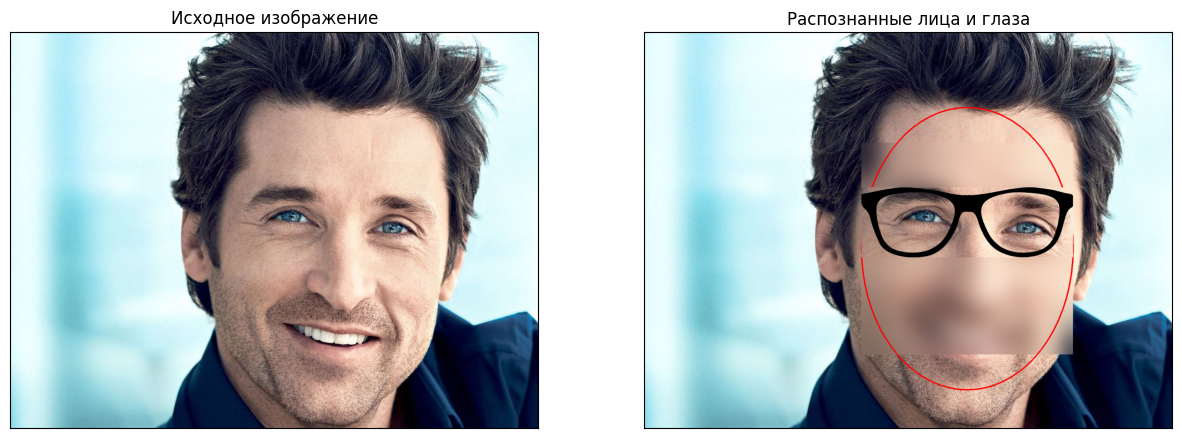

In [ ]:
change_face('./3.jpg', glass_width=0.2)

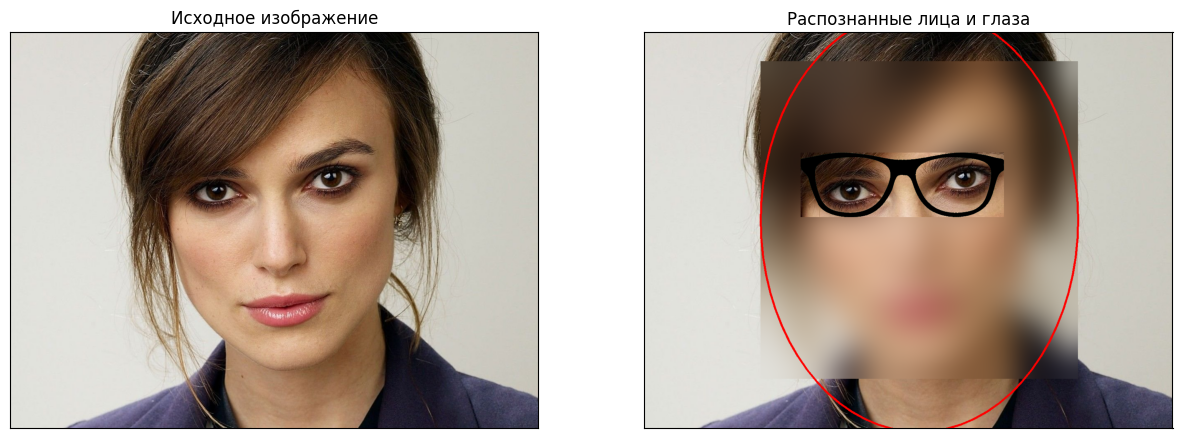

In [ ]:
change_face('./4.jpg')

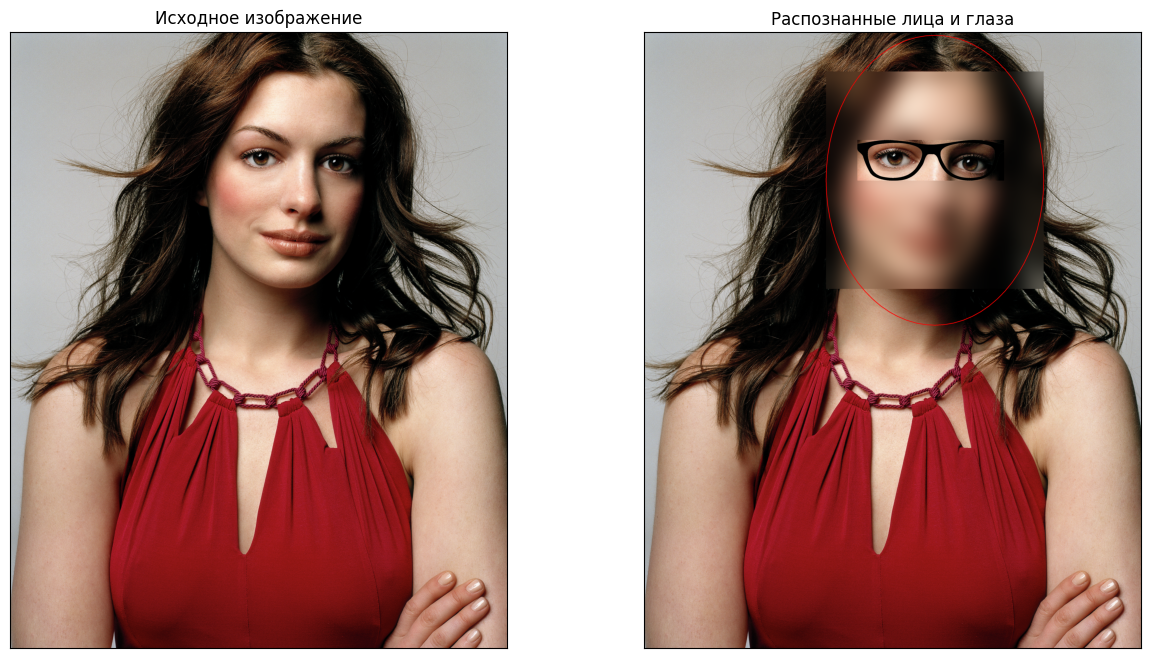

In [ ]:
change_face('./5.jpg')

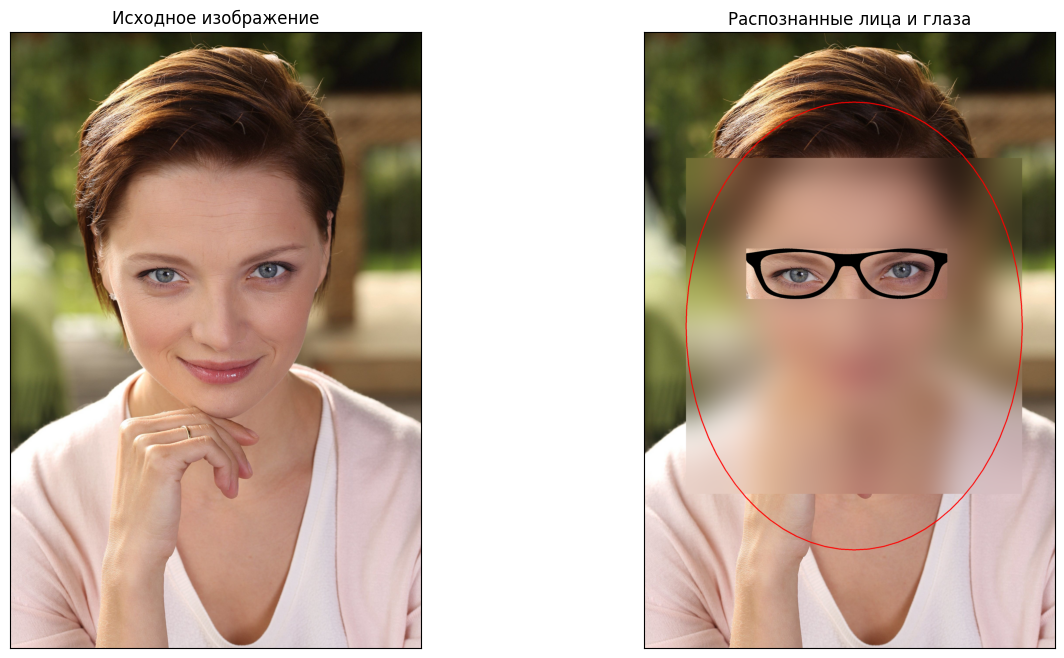

In [ ]:
change_face('./6.jpg')

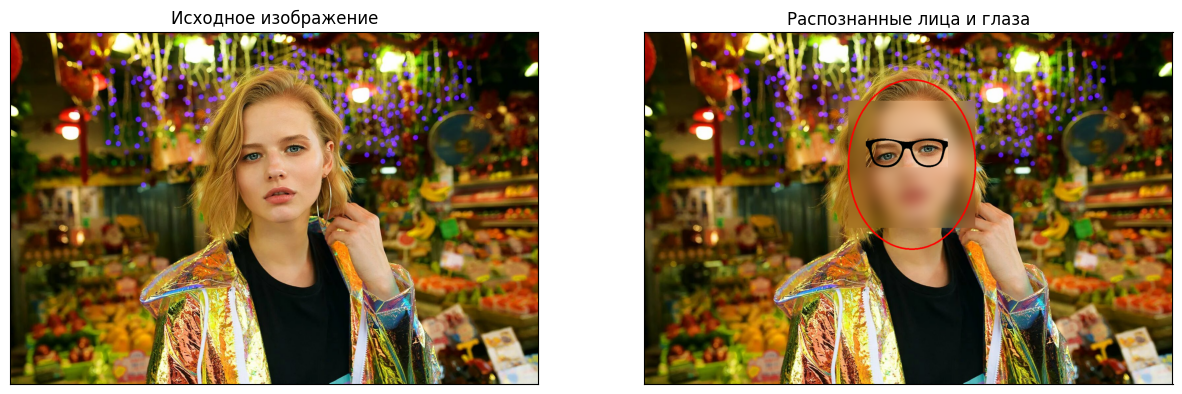

In [ ]:
change_face('./7.jpg')

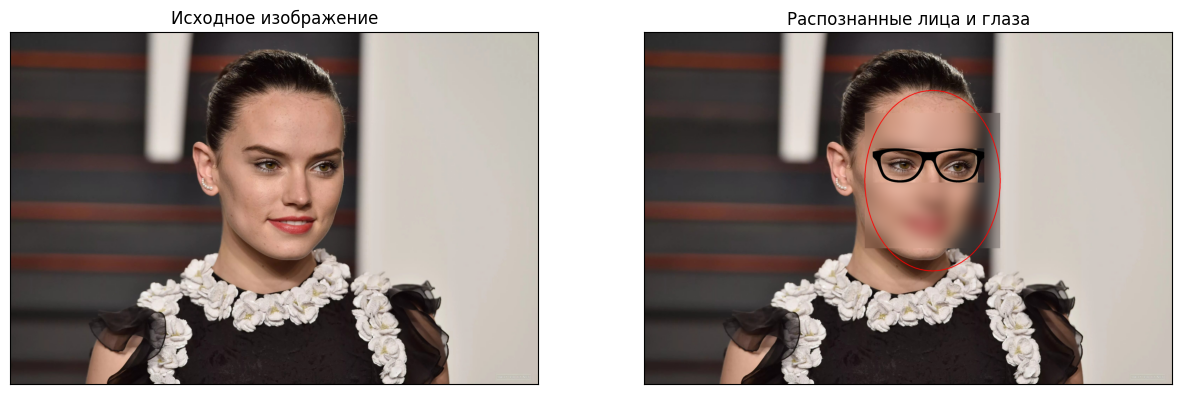

In [ ]:
change_face('./8.jpg')